# Crop Disease Detection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/clustering/crop-disease-detection/notebook.ipynb)

A deep learning project that identifies and classifies crop diseases from plant leaf images using a Convolutional Neural Network.

**Dataset:** Plant Village Dataset (Kaggle)
**Models Used:** CNN (Keras), Transfer Learning (MobileNetV2)
**Approach:** Image classification to detect healthy vs diseased crops

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")
print(f"TensorFlow version: {tf.__version__}")

Libraries loaded successfully
TensorFlow version: 2.19.0


In [2]:
# Upload kaggle.json when prompted
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset (small subset of Plant Village)
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip

print("Dataset downloaded successfully")

Saving kaggle (2).json to kaggle (2).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:02<00:00, 252MB/s]

Dataset downloaded successfully


In [3]:
# Load images from dataset
def load_dataset(base_path, img_size=64, max_per_class=200):
    images, labels = [], []
    classes = os.listdir(base_path)

    for cls in classes:
        cls_path = os.path.join(base_path, cls)
        if not os.path.isdir(cls_path):
            continue
        count = 0
        for fname in os.listdir(cls_path):
            if count >= max_per_class:
                break
            img_path = os.path.join(cls_path, fname)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(cls)
                count += 1

    return np.array(images), np.array(labels)

# Find dataset folder
base_path = 'PlantVillage'
if not os.path.exists(base_path):
    base_path = [d for d in os.listdir('.') if os.path.isdir(d)][0]

X_raw, y_raw = load_dataset(base_path)
print(f"Total images: {X_raw.shape}")
print(f"Classes found: {len(np.unique(y_raw))}")
print(f"Class names: {np.unique(y_raw)}")

Total images: (2952, 64, 64, 3)
Classes found: 15
Class names: ['Pepper__bell___Bacterial_spot' 'Pepper__bell___healthy'
 'Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy'
 'Tomato_Bacterial_spot' 'Tomato_Early_blight' 'Tomato_Late_blight'
 'Tomato_Leaf_Mold' 'Tomato_Septoria_leaf_spot'
 'Tomato_Spider_mites_Two_spotted_spider_mite' 'Tomato__Target_Spot'
 'Tomato__Tomato_YellowLeaf__Curl_Virus' 'Tomato__Tomato_mosaic_virus'
 'Tomato_healthy']


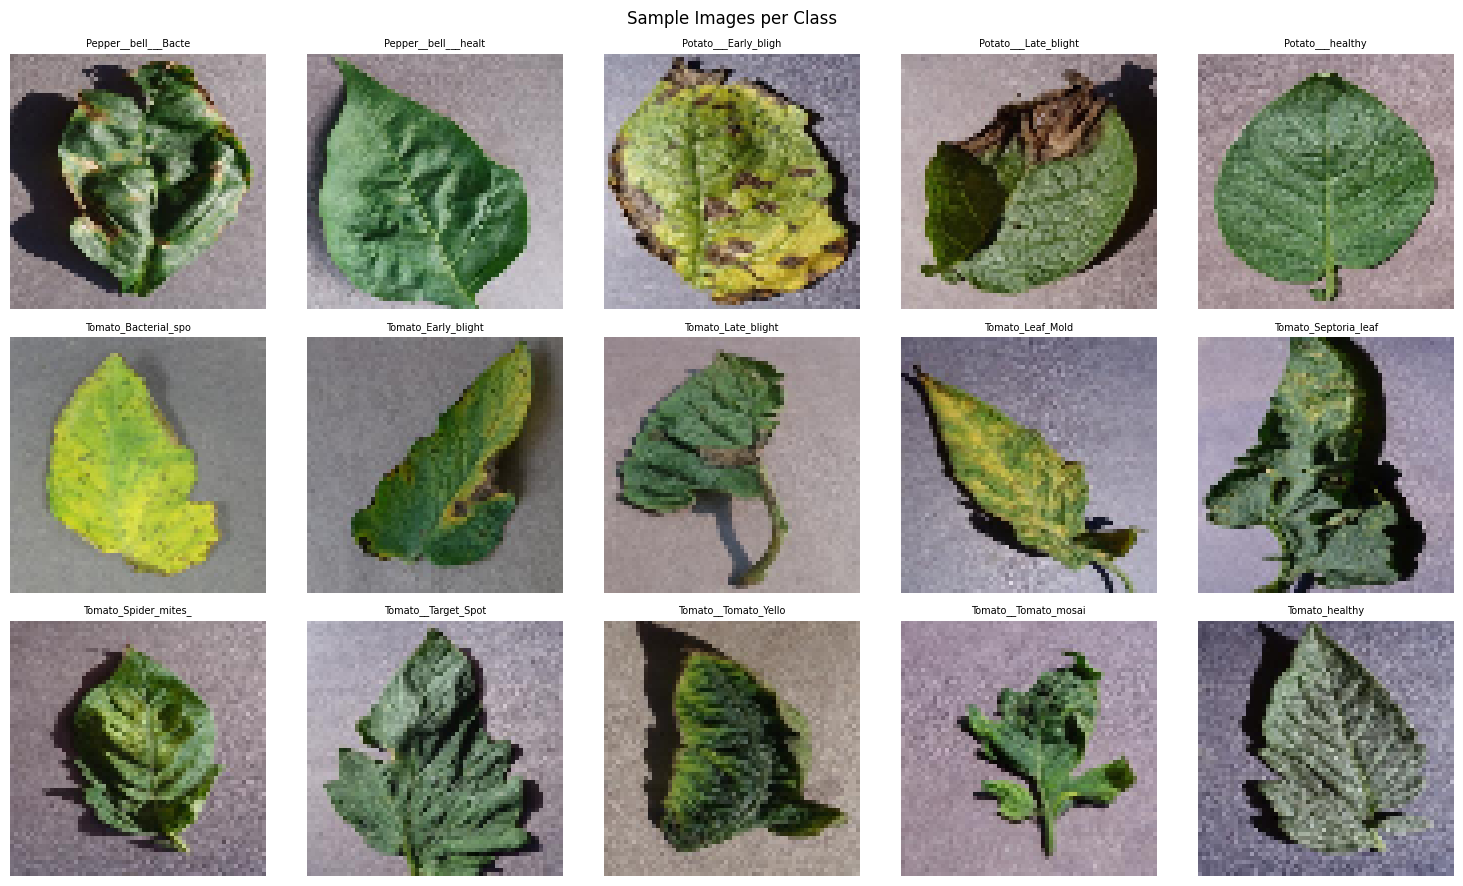

In [4]:
# Visualize sample images per class
classes = np.unique(y_raw)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, ax in enumerate(axes.flat):
    if i < len(classes):
        idx = np.where(y_raw == classes[i])[0][0]
        ax.imshow(X_raw[idx])
        ax.set_title(classes[i][:20], fontsize=7)
    ax.axis('off')

plt.suptitle("Sample Images per Class")
plt.tight_layout()
plt.show()

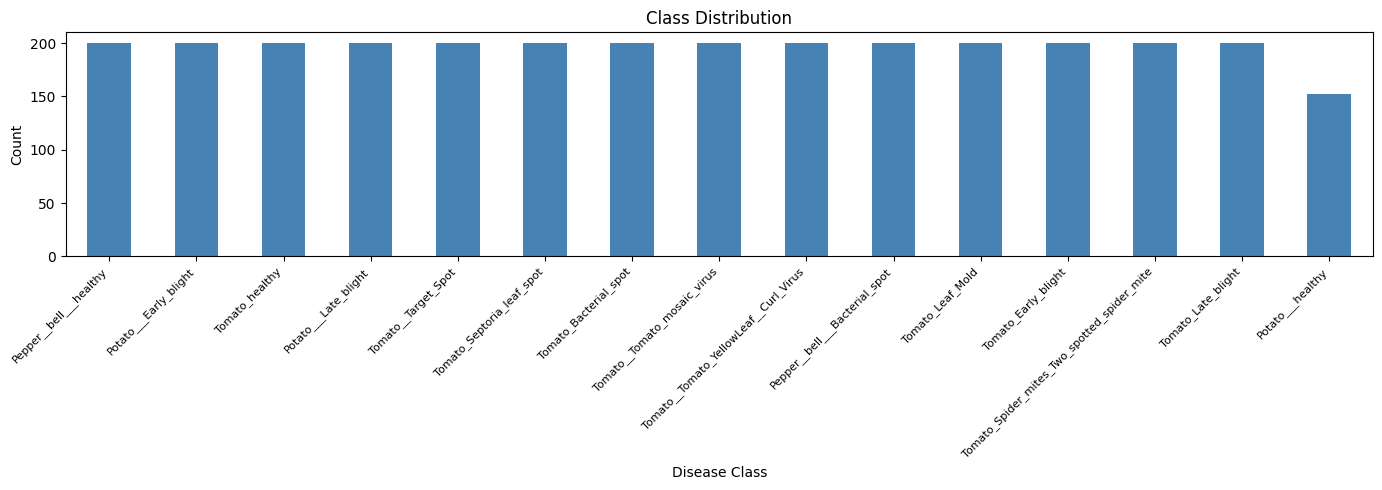

In [5]:
# Class distribution
class_counts = pd.Series(y_raw).value_counts()

plt.figure(figsize=(14, 5))
class_counts.plot(kind='bar', color='steelblue')
plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# Preprocess
X = X_raw.astype('float32') / 255.0

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
y_cat = to_categorical(y_encoded)

n_classes = len(le.classes_)
print(f"Number of classes: {n_classes}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Number of classes: 15
Training samples: 2361
Testing samples:  591


In [7]:
# Build CNN model
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,277,007 (4.87 MB)

 Trainable params: 1,277,007 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train CNN
cnn_history = cnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.1135 - loss: 2.6535 - val_accuracy: 0.2658 - val_loss: 2.4252
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3140 - loss: 2.0932 - val_accuracy: 0.4304 - val_loss: 1.7796
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4713 - loss: 1.6357 - val_accuracy: 0.5274 - val_loss: 1.4711
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5749 - loss: 1.2899 - val_accuracy: 0.5907 - val_loss: 1.2888
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6139 - loss: 1.1098 - val_accuracy: 0.5992 - val_loss: 1.1695
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6751 - loss: 0.9547 - val_accuracy: 0.6456 - val_loss: 1.1116
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7105 - loss: 0.8562 - val_accuracy: 0.6667 - val_loss: 0.9866
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7561 - loss: 0.7705 - val_accuracy: 0.7257 - val_los

In [9]:
# Build MobileNetV2 Transfer Learning model
base_model = MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

tl_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history = tl_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 48s 469ms/step - accuracy: 0.3875 - loss: 2.0106 - val_accuracy: 0.5865 - val_loss: 1.3084
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6299 - loss: 1.1649 - val_accuracy: 0.6245 - val_loss: 1.2050
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6930 - loss: 0.9262 - val_accuracy: 0.6456 - val_loss: 1.1455
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7637 - loss: 0.7444 - val_accuracy: 0.6751 - val_loss: 1.1050
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8112 - loss: 0.6170 - val_accuracy: 0.6920 - val_loss: 1.0796
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8230 - loss: 0.5600 - val_accuracy: 0.6624 - val_loss: 1.1001
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8611 - loss: 0.4584 - val_accuracy: 0.6793 - val_loss: 1.0943
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 

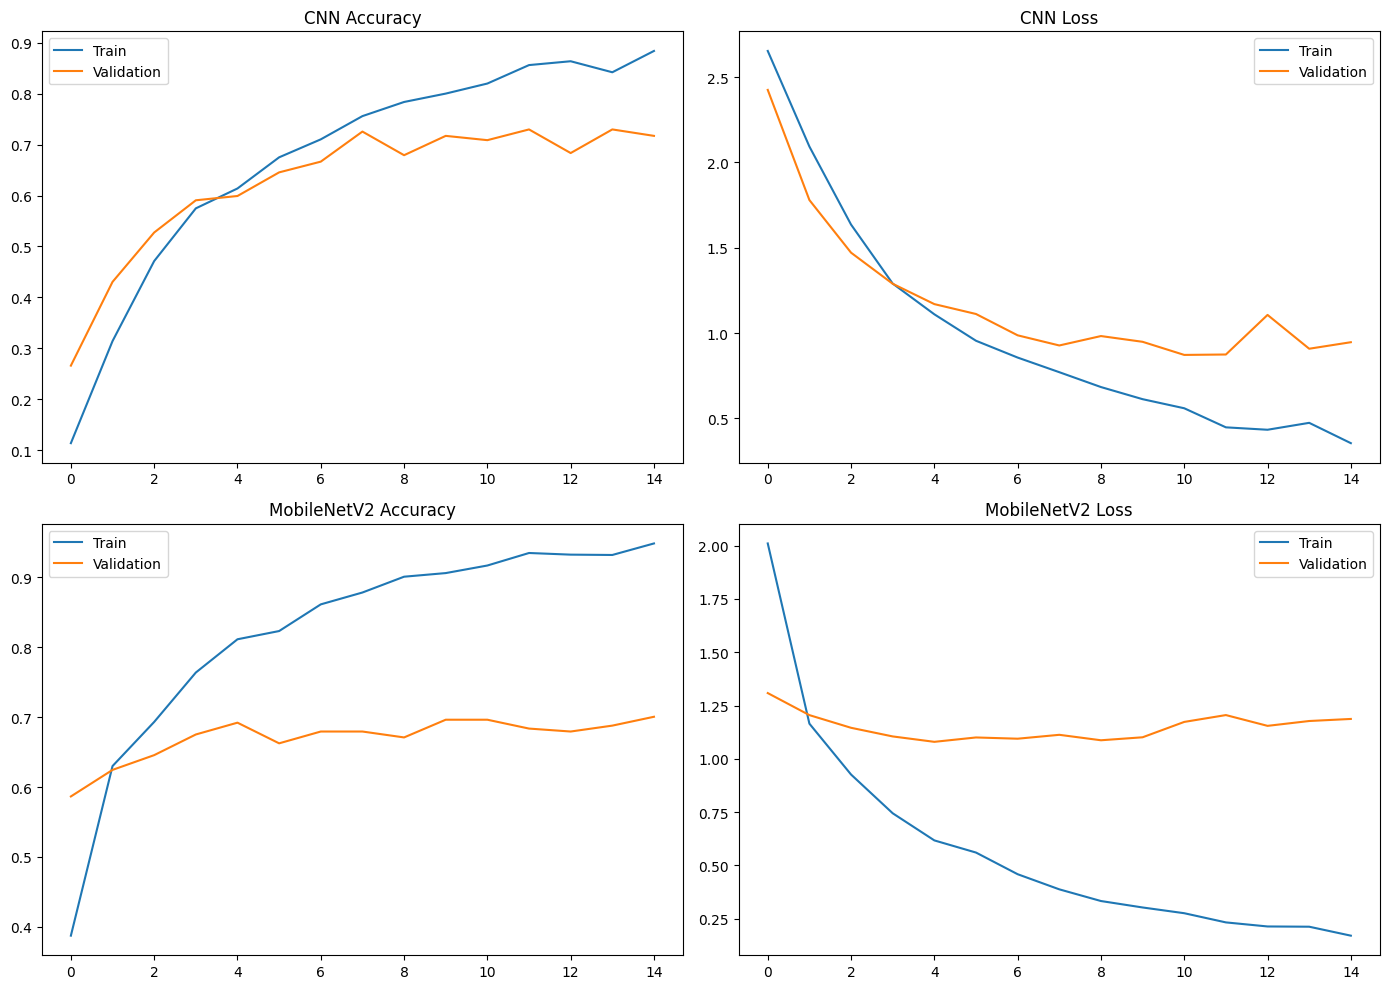

In [10]:
# Plot training history comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].plot(cnn_history.history['accuracy'], label='Train')
axes[0][0].plot(cnn_history.history['val_accuracy'], label='Validation')
axes[0][0].set_title("CNN Accuracy")
axes[0][0].legend()

axes[0][1].plot(cnn_history.history['loss'], label='Train')
axes[0][1].plot(cnn_history.history['val_loss'], label='Validation')
axes[0][1].set_title("CNN Loss")
axes[0][1].legend()

axes[1][0].plot(tl_history.history['accuracy'], label='Train')
axes[1][0].plot(tl_history.history['val_accuracy'], label='Validation')
axes[1][0].set_title("MobileNetV2 Accuracy")
axes[1][0].legend()

axes[1][1].plot(tl_history.history['loss'], label='Train')
axes[1][1].plot(tl_history.history['val_loss'], label='Validation')
axes[1][1].set_title("MobileNetV2 Loss")
axes[1][1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Evaluate both models
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
tl_loss, tl_acc  = tl_model.evaluate(X_test, y_test, verbose=0)

print(f"CNN Accuracy:         {cnn_acc:.4f}")
print(f"MobileNetV2 Accuracy: {tl_acc:.4f}")

CNN Accuracy:         0.7733
MobileNetV2 Accuracy: 0.7090


In [12]:
# Confusion matrix for best model
best_model = tl_model if tl_acc > cnn_acc else cnn_model
y_pred = np.argmax(best_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.64      0.68      0.66        40
                     Pepper__bell___healthy       0.84      0.80      0.82        40
                      Potato___Early_blight       0.79      0.95      0.86        40
                       Potato___Late_blight       0.71      0.62      0.67        40
                           Potato___healthy       0.76      0.84      0.80        31
                      Tomato_Bacterial_spot       0.89      0.85      0.87        40
                        Tomato_Early_blight       0.65      0.42      0.52        40
                         Tomato_Late_blight       0.68      0.70      0.69        40
                           Tomato_Leaf_Mold       0.73      0.68      0.70        40
                  Tomato_Septoria_leaf_spot       0.61      0.57      0.59        40
Tomato_Spider_mites_Two_

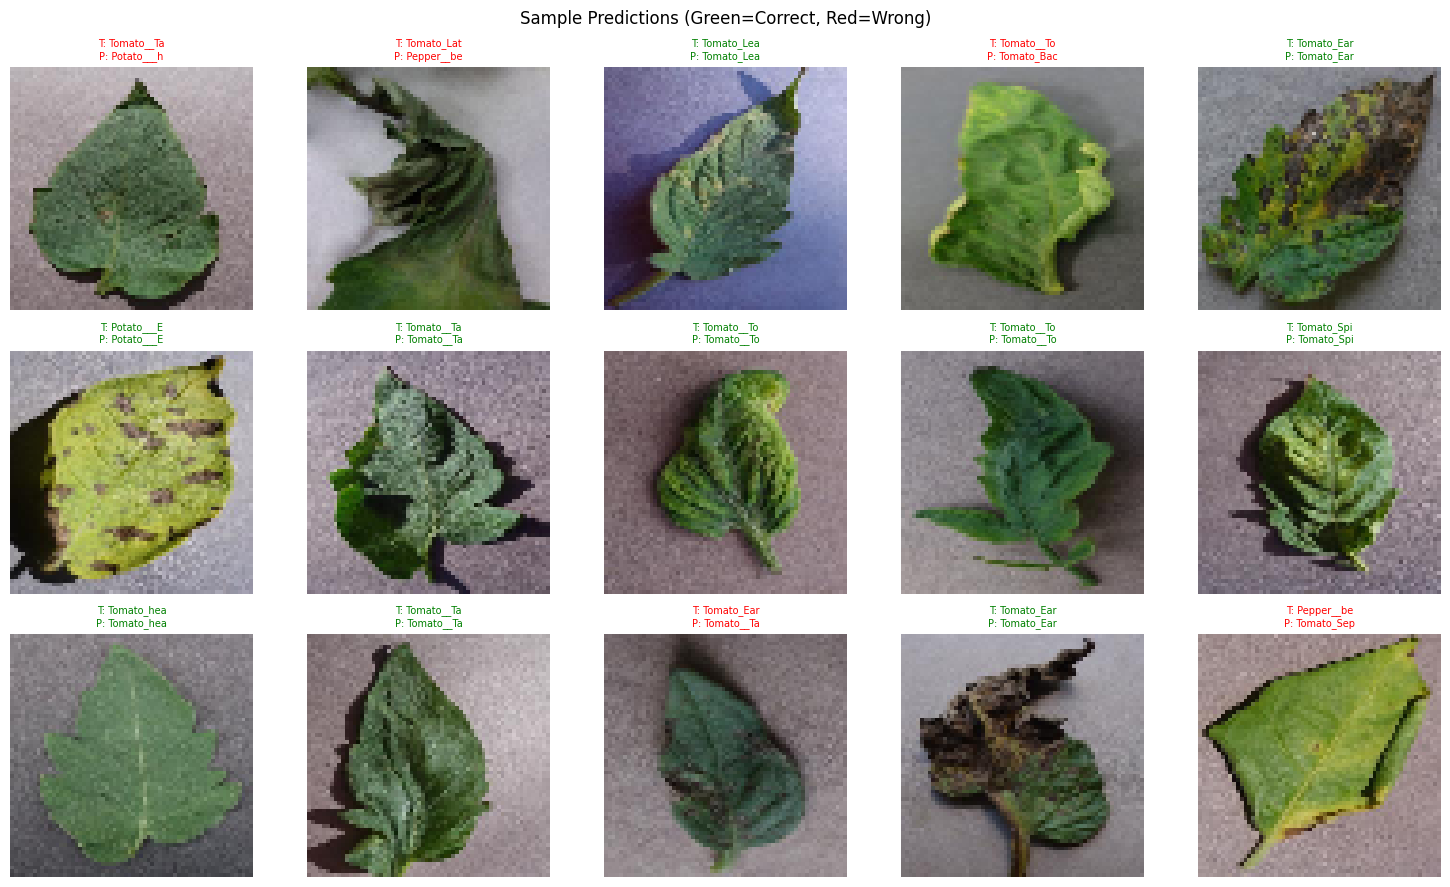

In [13]:
# Visualize predictions
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    true_label = le.classes_[y_true[i]]
    pred_label = le.classes_[y_pred[i]]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"T: {true_label[:10]}\nP: {pred_label[:10]}",
                 fontsize=7, color=color)
    ax.axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

## Results Summary

| Model | Test Accuracy |
|-------|--------------|
| CNN (from scratch) | 0.7733 |
| MobileNetV2 (Transfer Learning) | 0.7090 |

**CNN outperformed MobileNetV2 on this dataset.**

### Key Takeaways
- CNN from scratch performed better likely due to the small image size (64x64) not suiting MobileNetV2
- MobileNetV2 works better with larger input sizes (224x224)
- Data preprocessing and normalization are critical for CNN performance
- Increasing epochs or image size could improve MobileNetV2 performance